# Design of H-Profiles acc. to Neumann Regarding Lateral Flow

In [1]:
import ezdxf  # for DXF import
import shapely  # for planar geometric operations
import shapely.geometry as sg  # geometric objects
import ezdxf_shapely  # for conversion from DXF to shapely geometry
import numpy as np  # array computations
import math  # mathematical constants
from ipywidgets import interact  # interactive plots
from plot_helper import plot_geom, plot_geoms # module in local directory with helpers to plot geometries
from dataclasses import dataclass
import pandas as pd
import plotly.express as px

## Construct Parametrized H-Beam Cross-Sections

Define a class representing a H or I beam profile constructed by size parameters.

![](dxf/h_beam.png)

In [2]:
@dataclass()
class HBeam:
    w:float 
    s:float
    au:float
    al:float
    bu:float
    bl:float
    hu:float
    hl:float
    
    def __post_init__(self):
        self.coordinates = np.array([
            (self.w / 2, -self.s / 2 - self.hl),
            (self.w / 2, self.s / 2 + self.hu),
            (self.w / 2 - self.au, self.s / 2 + self.hu),
            (self.w / 2 - self.bu, self.s / 2),
            (-self.w / 2 + self.bu, self.s / 2),
            (-self.w / 2 + self.au, self.s / 2 + self.hu),
            (-self.w / 2, self.s / 2 + self.hu),
            (-self.w / 2, -self.s / 2 - self.hl),
            (-self.w / 2 + self.al, -self.s / 2 - self.hl),
            (-self.w / 2 + self.bl, -self.s / 2),
            (self.w / 2 - self.bl, -self.s / 2),
            (self.w / 2 - self.al, -self.s / 2 - self.hl),
        ])
        
        self.cross_section = sg.Polygon(self.coordinates).simplify(0)

Plot a beam with interactive parameters to play around with the measures.

In [3]:
beam = None

@interact
def draw_h_beam_interactively(w=100, s=20, au=10, al=10, bu=20, bl=20, hu=30, hl=30):
    global beam
    beam = HBeam(w,s,au,al,bu,bl,hu,hl)
    line = sg.LineString([(0, -50), (0, 50)])
    return plot_geoms([beam.cross_section])

interactive(children=(IntSlider(value=100, description='w', max=300, min=-100), IntSlider(value=20, descriptio…

## Division in Partial Cross-Sections acc. to Neumann

Define a class cutting the beam cross-section into devisions by the method of Neumann.

In [4]:
class NeumannDivision:
    def __init__(self, beam: HBeam):
        self.full = beam.cross_section

        # cut the upper and lower flanges by height of the bridge
        self.upper = shapely.clip_by_rect(self.full, -np.inf, beam.s / 2, np.inf, np.inf)
        self.lower = shapely.clip_by_rect(self.full, -np.inf, -np.inf, np.inf, -beam.s / 2)

        # create the inclined line that seperate bridge and gores
        left_split_line = sg.LineString([beam.coordinates[4], beam.coordinates[9]])
        right_split_line = sg.LineString([beam.coordinates[3], beam.coordinates[10]])

        # cut the bridge by its height and split by the lines
        bridge = shapely.clip_by_rect(self.full, -np.inf, -beam.s / 2, np.inf, beam.s / 2)
        left_gore, bridge = shapely.ops.split(bridge, left_split_line).geoms
        bridge, right_gore = shapely.ops.split(bridge, right_split_line).geoms

        self.gore = shapely.unary_union([left_gore, right_gore])
        self.bridge = bridge

        self.parts = [self.upper, self.lower, self.bridge, self.gore]
        self.part_areas = np.array([p.area for p in self.parts])

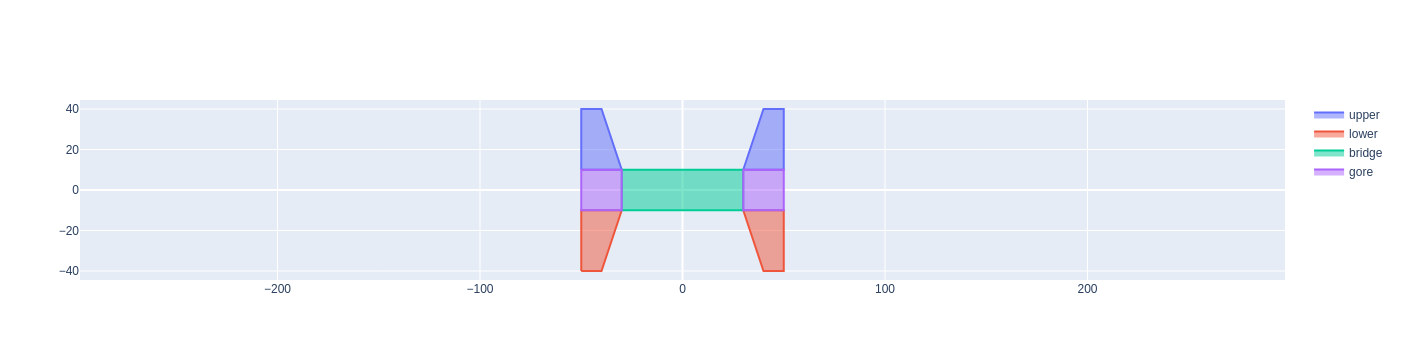

In [5]:
division = NeumannDivision(beam)
plot_geoms([division.upper, division.lower, division.bridge, division.gore], names=["upper", "lower", "bridge", "gore"])

## Calculate Partial Elongations and Theoretical Lateral Flows

Load a pass design for I50 beams as was given by Neumann from a CSV file.

Source: H. Neumann, „Zerlegung der Profile in Teile beim Kalibrieren von I-Stahl“, Neue Hütte, Bd. 7, Nr. 8, 1962.

In [6]:
calibration = pd.read_csv("I50_calibration_Neumann.csv")
calibration

,open,w,s,au,al,bu,bl,hu,hl
0,upper,388.0,100.0,101.0,105.0,154.0,160.0,95.00,93.50
1,lower,404.0,73.0,88.6,78.5,132.0,123.0,95.50,103.50
2,upper,419.0,54.5,67.1,69.5,102.5,107.0,101.75,100.75
3,lower,433.0,42.0,60.0,53.0,90.0,83.6,97.50,105.00
4,upper,440.0,33.2,46.1,47.8,70.7,74.0,99.40,99.40
5,lower,458.0,27.2,42.0,37.0,63.1,58.8,94.40,101.40
6,upper,469.0,23.0,32.8,34.0,50.5,53.0,95.50,95.50
7,lower,479.0,20.2,30.3,26.8,46.0,42.8,89.90,95.70
8,upper,488.0,18.4,24.1,25.0,37.4,39.2,90.10,90.00
9,lower,496.0,17.3,22.7,20.0,34.6,32.2,85.05,90.15


Create beam objects from the data in the table.

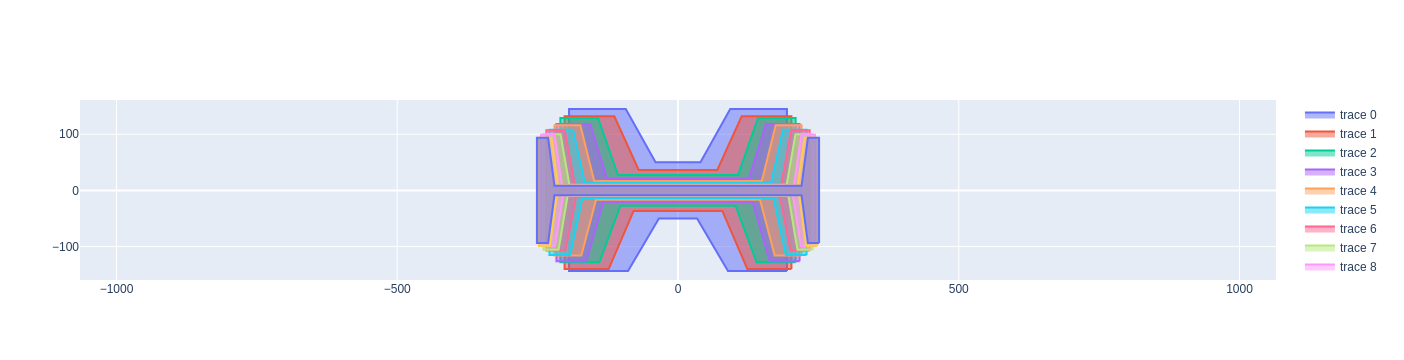

In [7]:
beams = [HBeam(c.w, c.s, c.au,c.al,c.bu,c.bl,c.hu,c.hl) for c in calibration.itertuples(index=False)]
plot_geoms([b.cross_section for b in beams])

Create the respective divisions from the beam geometries.

In [8]:
divisions = [NeumannDivision(b) for b in beams]

Create a pandas data frame with the cross-section areas of the full beam and its divisions for easier vectorized computation and plotting. The columns `open` and `closed` hold either the value of the upper or lower flange depending on where the opening of the roll gap is. We can also get information about the division according to Brovot in one ride by summing gore and bridge.

In [9]:
areas = pd.DataFrame([dict(
    full=d.full.area,
    upper=d.upper.area,
    lower=d.lower.area,
    gore=d.gore.area,
    bridge=d.bridge.area,
    gore_bridge=d.gore.area + d.bridge.area,
) for d in divisions])
areas["open"] = areas.upper.where(calibration.open == "upper", areas.lower)
areas["closed"] = areas.upper.where(calibration.open == "lower", areas.lower)
areas

,full,upper,lower,gore,bridge,gore_bridge,open,closed
0,87802.500,24225.000,24777.500,31400.00,7400.00,38800.0,24225.00,24777.500
1,71414.550,21067.300,20855.250,18615.00,10877.00,29492.0,20855.25,21067.300
2,57874.675,17256.800,17782.375,11417.75,11417.75,22835.5,17256.80,17782.375
3,47154.000,14625.000,14343.000,7291.20,10894.80,18186.0,14343.00,14625.000
4,38324.840,11609.920,12106.920,4804.04,9803.96,14608.0,11609.92,12106.920
5,32093.160,9921.440,9714.120,3315.68,9141.92,12457.6,9714.12,9921.440
6,27050.650,7955.150,8308.500,2380.50,8406.50,10787.0,7955.15,8308.500
7,23195.890,6859.370,6660.720,1793.76,7882.04,9675.8,6660.72,6859.370
8,20298.350,5541.150,5778.000,1409.44,7569.76,8979.2,5541.15,5778.000
9,18159.995,4873.365,4705.830,1155.64,7425.16,8580.8,4705.83,4873.365


Calculating the elongations in the passes by a rolling window operation. First row now holds `NaN` values, since there is no predecessor. We have to assign the `open` and `closed` columns manually again, since the row pair refer to different flanges.

In [10]:
elongations = areas.rolling(2).apply(lambda pair: pair.iloc[0] / pair.iloc[1])
elongations["open"] = elongations.upper.where(calibration.open == "upper", elongations.lower)
elongations["closed"] = elongations.upper.where(calibration.open == "lower", elongations.lower)
elongations

,full,upper,lower,gore,bridge,gore_bridge,open,closed
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.229476,1.149886,1.188070,1.686812,0.680335,1.315611,1.188070,1.149886
2,1.233952,1.220812,1.172805,1.630356,0.952640,1.291498,1.220812,1.172805
3,1.227355,1.179952,1.239795,1.565963,1.048000,1.255664,1.239795,1.179952
4,1.230377,1.259699,1.184694,1.517723,1.111265,1.244934,1.259699,1.184694
5,1.194175,1.170185,1.246322,1.448885,1.072418,1.172618,1.246322,1.170185
6,1.186410,1.247172,1.169179,1.392850,1.087482,1.154872,1.247172,1.169179
7,1.166183,1.159749,1.247388,1.327101,1.066539,1.114843,1.247388,1.159749
8,1.142748,1.237896,1.152773,1.272676,1.041254,1.077579,1.237896,1.152773
9,1.117751,1.137027,1.227839,1.219619,1.019474,1.046429,1.227839,1.137027


We plot the elongations of the divisions to compare. The gore has alomst everywhere the highest elongation, and the flanges have higher elongation than the bridge.

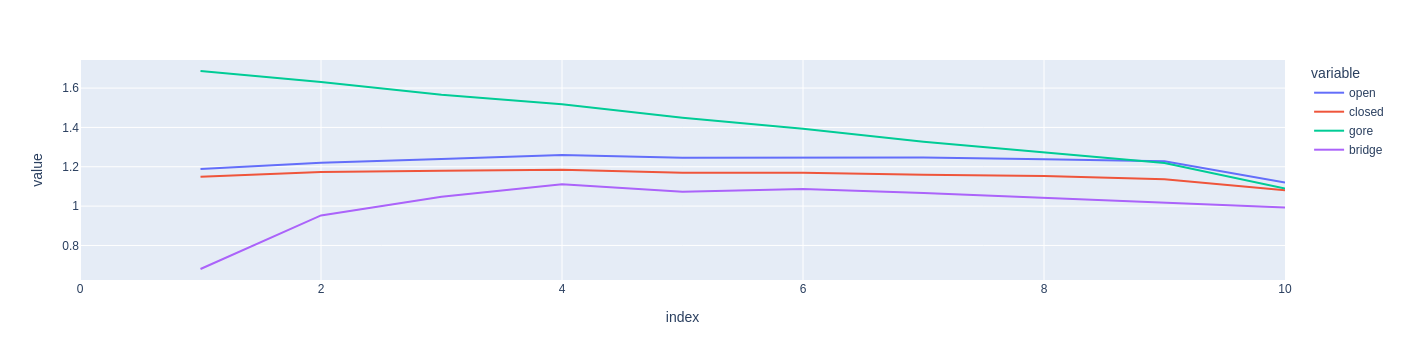

In [11]:
px.line(elongations, y=["open", "closed", "gore", "bridge"])

The open flanges should have higher elongations than the closed ones to prevent stucking in the closed. We can easily check this for all passes. Note that the first value is always `False`, since `NaN` is neither equal nor unequal to itself.

In [12]:
elongations.open > elongations.closed

0     False
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
dtype: bool

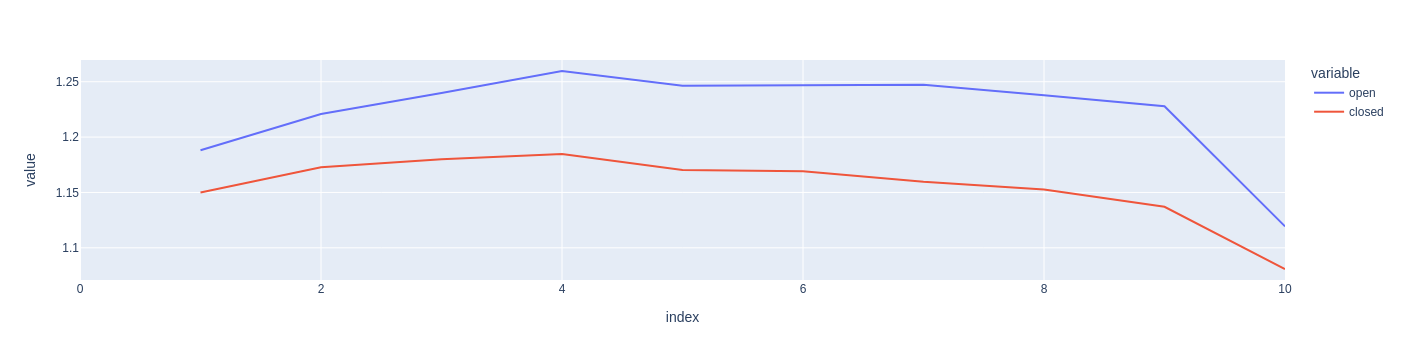

In [13]:
px.line(elongations, y=["open", "closed"])

Usually, in the first passes, where material is thick and hot and lateral flow therefore easy, a high reduction of the bridge is applied. In the last passes, lateral flow is more hindered, so a high reduction of the brigde would lead to waving. To prevent this, one chooses the bridge elongation there smaller than the mean. These rules, however, apply for the division according to Brovot, where gore and bridge are taken as one.

In [14]:
elongations.gore_bridge > elongations.full

0     False
1      True
2      True
3      True
4      True
5     False
6     False
7     False
8     False
9     False
10    False
dtype: bool

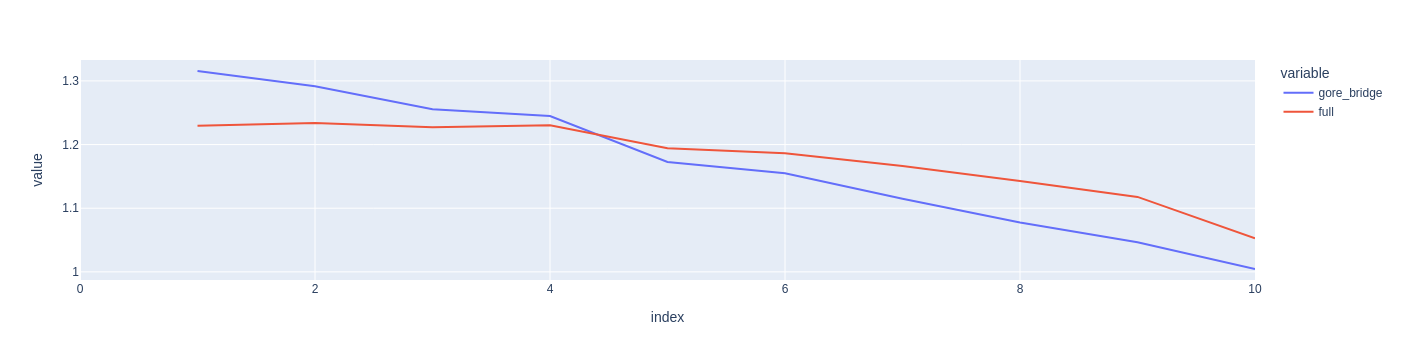

In [15]:
px.line(elongations, y=["gore_bridge", "full"])

We can calculate the theoretical lateral flows between the divisions from the areas and elongations. Unfortunately, we can not use the `/` operator here for vectroized calculation, since it does align the vectors wrongly. We use instead the `.div()` method to be able to specify the correct axis. The sign convention is that positive values mean receiving of volume.

In [16]:
lateral_flows = areas * (1 - elongations.div(elongations["full"], axis=0))
lateral_flows

,full,upper,lower,gore,bridge,gore_bridge,open,closed
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,1363.789579,702.361271,-6924.328265,4858.177415,-2066.150850,702.361271,1363.789579
2,0.0,183.764594,881.185875,-3667.930371,2602.979901,-1064.950470,183.764594,881.185875
3,0.0,564.840747,-145.377010,-2011.531868,1592.068132,-419.463737,-145.377010,564.840747
4,0.0,-276.681031,449.517020,-1121.948748,949.112758,-172.835989,-276.681031,449.517020
5,0.0,199.311476,-424.195533,-707.215448,932.099505,224.884057,-424.195533,199.311476
6,0.0,-407.423238,120.672432,-414.216980,700.967785,286.750805,-407.423238,120.672432
7,0.0,37.841337,-463.805735,-247.515021,673.479419,425.964398,-463.805735,37.841337
8,0.0,-461.374285,-50.688867,-160.250505,672.313658,512.063152,-461.374285,-50.688867
9,0.0,-84.045641,-463.479383,-105.320785,652.845809,547.525024,-463.479383,-84.045641


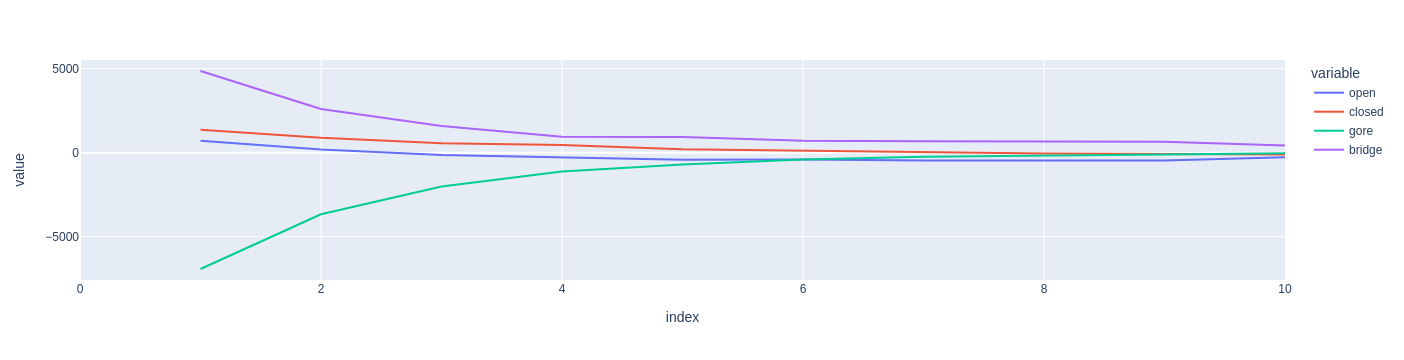

In [17]:
px.line(lateral_flows, y=["open", "closed", "gore", "bridge"])

Lets check, that the lateral flows sum up to zero. We have to include only the mutually exclusive divisions, of course.

In [23]:
lateral_flows["sum"] = lateral_flows[["upper", "lower", "bridge", "gore"]].sum(axis=1, skipna=False)
lateral_flows

,full,upper,lower,gore,bridge,gore_bridge,open,closed,sum,abs_sum
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,0.0,1363.789579,702.361271,-6924.328265,4858.177415,-2066.150850,702.361271,1363.789579,1.818989e-12,13848.656530
2,0.0,183.764594,881.185875,-3667.930371,2602.979901,-1064.950470,183.764594,881.185875,-4.092726e-12,7335.860742
3,0.0,564.840747,-145.377010,-2011.531868,1592.068132,-419.463737,-145.377010,564.840747,5.684342e-12,4313.817758
4,0.0,-276.681031,449.517020,-1121.948748,949.112758,-172.835989,-276.681031,449.517020,-3.183231e-12,2797.259557
5,0.0,199.311476,-424.195533,-707.215448,932.099505,224.884057,-424.195533,199.311476,1.273293e-11,2262.821961
6,0.0,-407.423238,120.672432,-414.216980,700.967785,286.750805,-407.423238,120.672432,-1.074341e-11,1643.280436
7,0.0,37.841337,-463.805735,-247.515021,673.479419,425.964398,-463.805735,37.841337,-5.798029e-12,1422.641511
8,0.0,-461.374285,-50.688867,-160.250505,672.313658,512.063152,-461.374285,-50.688867,-6.252776e-13,1344.627316
9,0.0,-84.045641,-463.479383,-105.320785,652.845809,547.525024,-463.479383,-84.045641,1.250555e-12,1305.691619


In the first passes, where material is hot and thick, lateral flows are easily possible. In the last passes it is more hindered. So we should design the pass sequence with lower lateral flows to the end. So we check the total absolute flow in each pass.

In [24]:
lateral_flows["abs_sum"] = lateral_flows[["upper", "lower", "bridge", "gore"]].abs().sum(axis=1, skipna=False)
lateral_flows

,full,upper,lower,gore,bridge,gore_bridge,open,closed,sum,abs_sum
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,1363.789579,702.361271,-6924.328265,4858.177415,-2066.150850,702.361271,1363.789579,1.818989e-12,13848.656530
2,0.0,183.764594,881.185875,-3667.930371,2602.979901,-1064.950470,183.764594,881.185875,-4.092726e-12,7335.860742
3,0.0,564.840747,-145.377010,-2011.531868,1592.068132,-419.463737,-145.377010,564.840747,5.684342e-12,4313.817758
4,0.0,-276.681031,449.517020,-1121.948748,949.112758,-172.835989,-276.681031,449.517020,-3.183231e-12,2797.259557
5,0.0,199.311476,-424.195533,-707.215448,932.099505,224.884057,-424.195533,199.311476,1.273293e-11,2262.821961
6,0.0,-407.423238,120.672432,-414.216980,700.967785,286.750805,-407.423238,120.672432,-1.074341e-11,1643.280436
7,0.0,37.841337,-463.805735,-247.515021,673.479419,425.964398,-463.805735,37.841337,-5.798029e-12,1422.641511
8,0.0,-461.374285,-50.688867,-160.250505,672.313658,512.063152,-461.374285,-50.688867,-6.252776e-13,1344.627316
9,0.0,-84.045641,-463.479383,-105.320785,652.845809,547.525024,-463.479383,-84.045641,1.250555e-12,1305.691619


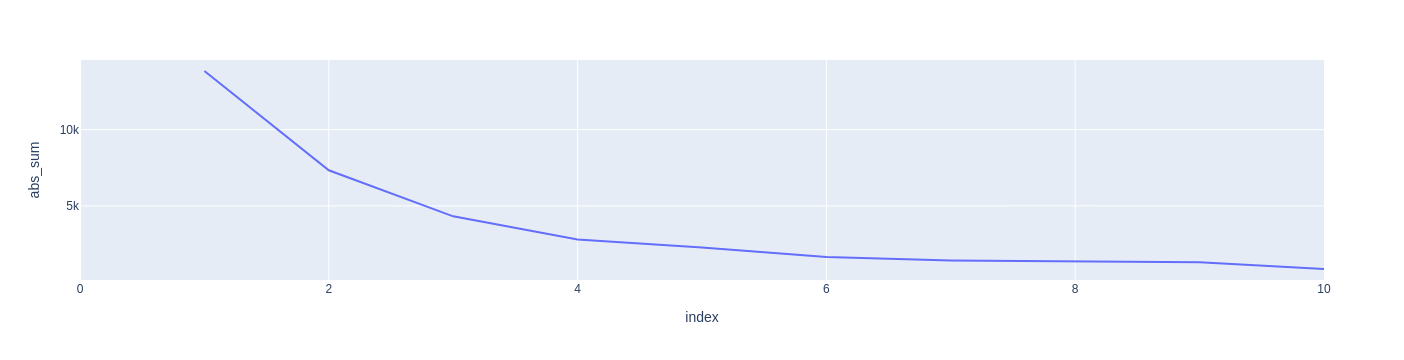

In [25]:
px.line(lateral_flows, y="abs_sum")